In [86]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
from sklearn.metrics import roc_auc_score,roc_curve

In [87]:
df=pd.read_csv('zoo.csv')
df.head()

,animal name,hair,feathers,eggs,milk,airborne,aquatic,predator,toothed,backbone,breathes,venomous,fins,legs,tail,domestic,catsize,type
0,aardvark,1,0,0,1,0,0,1,1,1,1,0,0,4,0,0,1,1
1,antelope,1,0,0,1,0,0,0,1,1,1,0,0,4,1,0,1,1
2,bass,0,0,1,0,0,1,1,1,1,0,0,1,0,1,0,0,4
3,bear,1,0,0,1,0,0,1,1,1,1,0,0,4,0,0,1,1
4,boar,1,0,0,1,0,0,1,1,1,1,0,0,4,1,0,1,1


In [88]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 101 entries, 0 to 100
Data columns (total 18 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   animal name  101 non-null    object
 1   hair         101 non-null    int64 
 2   feathers     101 non-null    int64 
 3   eggs         101 non-null    int64 
 4   milk         101 non-null    int64 
 5   airborne     101 non-null    int64 
 6   aquatic      101 non-null    int64 
 7   predator     101 non-null    int64 
 8   toothed      101 non-null    int64 
 9   backbone     101 non-null    int64 
 10  breathes     101 non-null    int64 
 11  venomous     101 non-null    int64 
 12  fins         101 non-null    int64 
 13  legs         101 non-null    int64 
 14  tail         101 non-null    int64 
 15  domestic     101 non-null    int64 
 16  catsize      101 non-null    int64 
 17  type         101 non-null    int64 
dtypes: int64(17), object(1)
memory usage: 14.3+ KB


In [89]:
df.isna().sum()

animal name    0
hair           0
feathers       0
eggs           0
milk           0
airborne       0
aquatic        0
predator       0
toothed        0
backbone       0
breathes       0
venomous       0
fins           0
legs           0
tail           0
domestic       0
catsize        0
type           0
dtype: int64

In [90]:
df.duplicated().sum()

np.int64(0)

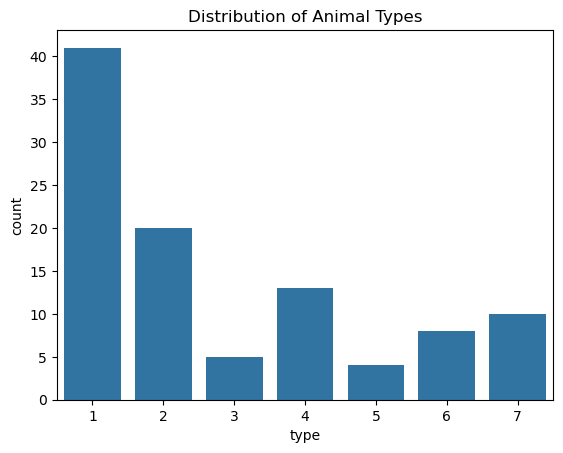

In [91]:
sns.countplot(x='type', data=df)
plt.title('Distribution of Animal Types')
plt.show()

In [92]:
df1=df.drop(['animal name'],axis=1)
df1.head()

,hair,feathers,eggs,milk,airborne,aquatic,predator,toothed,backbone,breathes,venomous,fins,legs,tail,domestic,catsize,type
0,1,0,0,1,0,0,1,1,1,1,0,0,4,0,0,1,1
1,1,0,0,1,0,0,0,1,1,1,0,0,4,1,0,1,1
2,0,0,1,0,0,1,1,1,1,0,0,1,0,1,0,0,4
3,1,0,0,1,0,0,1,1,1,1,0,0,4,0,0,1,1
4,1,0,0,1,0,0,1,1,1,1,0,0,4,1,0,1,1


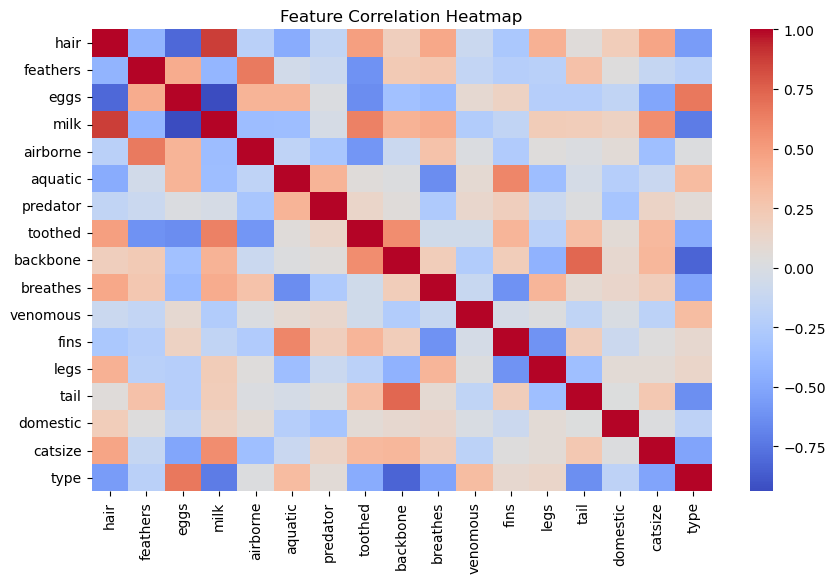

In [93]:
plt.figure(figsize=(10,6))
sns.heatmap(df1.corr(), cmap='coolwarm', annot=False)
plt.title("Feature Correlation Heatmap")
plt.show()


In [94]:
df1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 101 entries, 0 to 100
Data columns (total 17 columns):
 #   Column    Non-Null Count  Dtype
---  ------    --------------  -----
 0   hair      101 non-null    int64
 1   feathers  101 non-null    int64
 2   eggs      101 non-null    int64
 3   milk      101 non-null    int64
 4   airborne  101 non-null    int64
 5   aquatic   101 non-null    int64
 6   predator  101 non-null    int64
 7   toothed   101 non-null    int64
 8   backbone  101 non-null    int64
 9   breathes  101 non-null    int64
 10  venomous  101 non-null    int64
 11  fins      101 non-null    int64
 12  legs      101 non-null    int64
 13  tail      101 non-null    int64
 14  domestic  101 non-null    int64
 15  catsize   101 non-null    int64
 16  type      101 non-null    int64
dtypes: int64(17)
memory usage: 13.5 KB


In [95]:
# Simple IQR method for numeric columns
Q1 = df1.quantile(0.25)
Q3 = df1.quantile(0.75)
IQR = Q3 - Q1
df1 = df1[~((df1 < (Q1 - 1.5 * IQR)) | (df1 > (Q3 + 1.5 * IQR))).any(axis=1)]


In [96]:
X = df1.drop(['type'], axis=1)
y = df1['type'] 

In [97]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [98]:
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, roc_auc_score
from sklearn.preprocessing import label_binarize
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

def evaluate_cif(y, yhat):
    # Confusion Matrix
    cm = confusion_matrix(y, yhat)
    plt.figure(figsize=(4, 3))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
    plt.title('Confusion Matrix')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.show()

    # Classification Report
    print("\nClassification Report:")
    print(classification_report(y, yhat))

    # ROC Curve and AUC
    plt.figure(figsize=(5, 4))
    plt.title('ROC Curve')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')

    unique_classes = np.unique(y)

    # ---- Binary classification ----
    if len(unique_classes) == 2:
        pos_label = unique_classes[1]  # Automatically detect positive label
        fpr, tpr, _ = roc_curve(y, yhat, pos_label=pos_label)
        auc = roc_auc_score(y, yhat)
        plt.plot(fpr, tpr, label=f'AUC = {auc:.2f}')
        plt.legend()

    # ---- Multiclass classification ----
    else:
        y_bin = label_binarize(y, classes=unique_classes)
        yhat_bin = label_binarize(yhat, classes=unique_classes)
        auc = roc_auc_score(y_bin, yhat_bin, average='macro')
        for i in range(y_bin.shape[1]):
            fpr, tpr, _ = roc_curve(y_bin[:, i], yhat_bin[:, i])
            plt.plot(fpr, tpr, label=f'Class {unique_classes[i]}')
        plt.legend(title=f'Macro AUC = {auc:.2f}')

    plt.plot([0, 1], [0, 1], 'k--')
    plt.show()


In [99]:
x_train,x_test,y_train,y_test=train_test_split(X,y,test_size=0.2)
x_train.shape,x_test.shape,y_train.shape,y_test.shape

((26, 16), (7, 16), (26,), (7,))

In [100]:
model=KNeighborsClassifier(n_neighbors=3,metric='euclidean')
model.fit(x_train,y_train)

KNeighborsClassifier(metric='euclidean', n_neighbors=3)

In [101]:
yhat_train=model.predict(x_train)


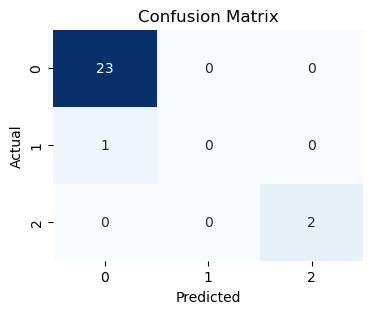


Classification Report:
              precision    recall  f1-score   support

           1       0.96      1.00      0.98        23
           3       0.00      0.00      0.00         1
           5       1.00      1.00      1.00         2

    accuracy                           0.96        26
   macro avg       0.65      0.67      0.66        26
weighted avg       0.92      0.96      0.94        26



C:\Users\hp\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\hp\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\hp\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


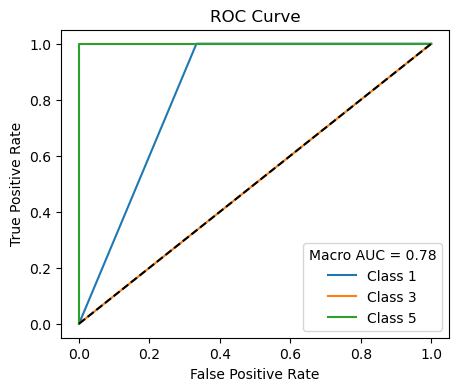

In [102]:
evaluate_cif(y_train,yhat_train)

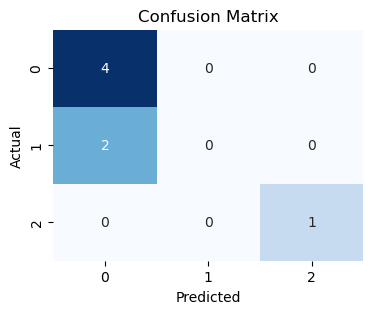


Classification Report:
              precision    recall  f1-score   support

           1       0.67      1.00      0.80         4
           3       0.00      0.00      0.00         2
           5       1.00      1.00      1.00         1

    accuracy                           0.71         7
   macro avg       0.56      0.67      0.60         7
weighted avg       0.52      0.71      0.60         7



C:\Users\hp\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\hp\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\hp\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


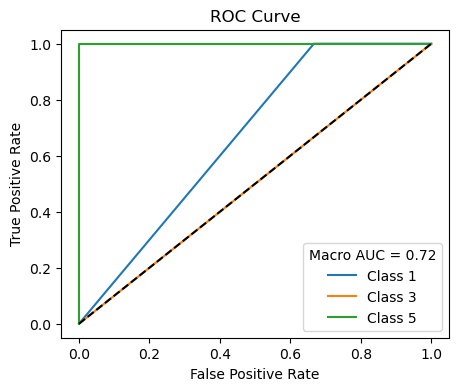

In [103]:
yhat_test=model.predict(x_test)
evaluate_cif(y_test,yhat_test)

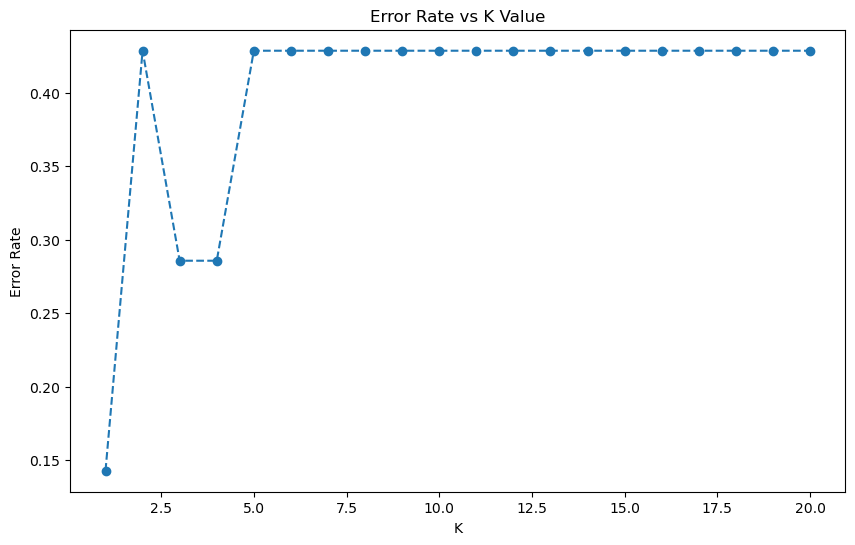

In [104]:
error_rate = []
for i in range(1, 21):
    knn = KNeighborsClassifier(n_neighbors=i)
    knn.fit(x_train, y_train)
    pred_i = knn.predict(x_test)
    error_rate.append(np.mean(pred_i != y_test))

plt.figure(figsize=(10,6))
plt.plot(range(1,21), error_rate, marker='o', linestyle='--')
plt.title('Error Rate vs K Value')
plt.xlabel('K')
plt.ylabel('Error Rate')
plt.show()


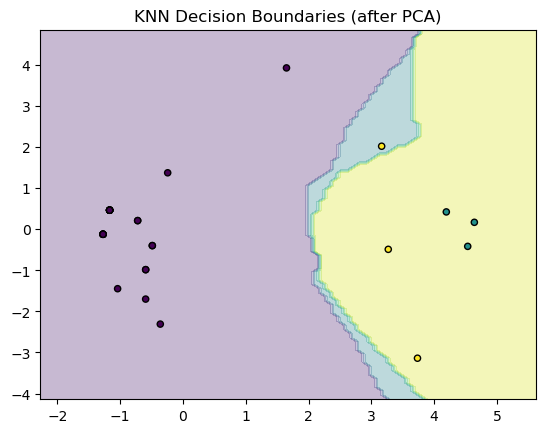

In [105]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
X_reduced = pca.fit_transform(X_scaled)

knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_reduced, y)

# Create meshgrid
x_min, x_max = X_reduced[:, 0].min() - 1, X_reduced[:, 0].max() + 1
y_min, y_max = X_reduced[:, 1].min() - 1, X_reduced[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.1),
                     np.arange(y_min, y_max, 0.1))

Z = knn.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

plt.contourf(xx, yy, Z, alpha=0.3)
plt.scatter(X_reduced[:, 0], X_reduced[:, 1], c=pd.factorize(y)[0], s=20, edgecolor='k')
plt.title('KNN Decision Boundaries (after PCA)')
plt.show()


#### Key Hyperparameters in KNN:
###### The main hyperparameters in KNN are n_neighbors, which defines how many nearby points influence the classification or regression; weights, which determines whether all neighbors contribute equally (uniform) or closer ones have more influence (distance); and metric, which specifies the distance measure used to find neighbors. Additionally, algorithm (like auto, ball_tree, kd_tree, or brute) controls how neighbors are searched efficiently, and p defines the power parameter for the Minkowski distance (p=1 → Manhattan, p=2 → Euclidean).

#### Distance Metrics in KNN:
###### Common distance metrics used in KNN include Euclidean distance (straight-line distance, most common), Manhattan distance (sum of absolute differences), and Minkowski distance (a generalization of both). For categorical or mixed data, Hamming distance or Cosine similarity may be used. The choice of distance metric affects how similarity between data points is measured and can influence the model’s accuracy.`